In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import scipy
from sklearn.model_selection import train_test_split
import torch

In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import datasets
import models
import utils

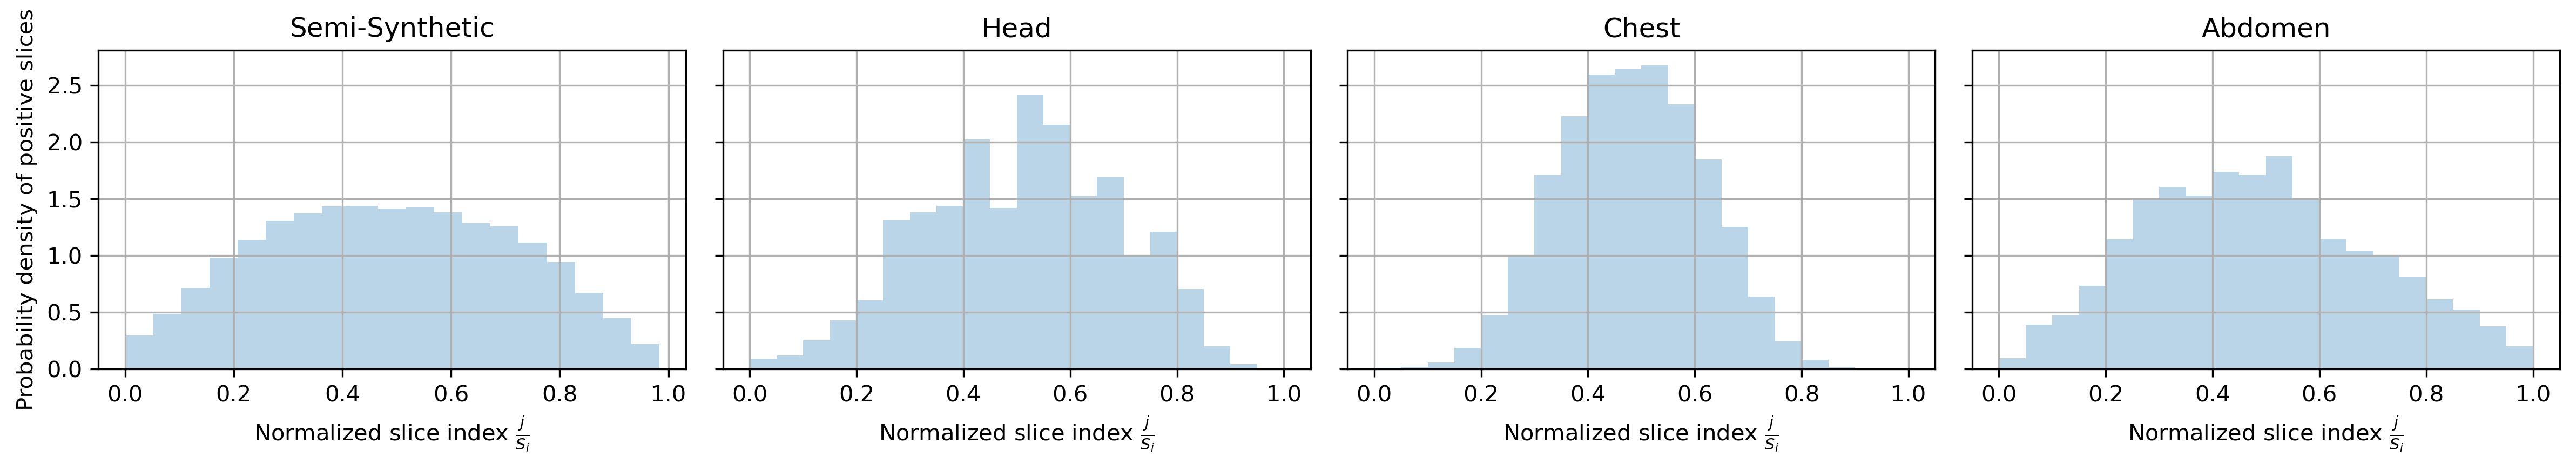

In [3]:
semi_synthetic_train_dataset = datasets.ShiftedMeanMILDataset(n=10_000, r=12, s_low=20, s_high=60, delta=0.5, seed=1001)
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed=1001"
head_train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_PE/ViT_B_16/seed=1001"
chest_train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_AT/ViT_B_16/seed=1001"
abdomen_train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))

ncols, nrows = 4, 1
fig, axs = plt.subplots(dpi=300, figsize=(ncols * 4, nrows * 3), ncols=ncols, nrows=nrows, sharey=True)

values = [
    j / semi_synthetic_train_dataset.lengths[i] 
    for i, y_i in enumerate(semi_synthetic_train_dataset.y) if y_i == 1.0 
    for j in range(semi_synthetic_train_dataset.u[i], semi_synthetic_train_dataset.u[i] + semi_synthetic_train_dataset.r)
]
        
axs[0].hist(values, alpha=0.3, bins=np.linspace(start=min(values), stop=max(values), num=20), density=True, color="#1F77B4")
axs[0].set_title("Semi-Synthetic")
axs[0].set_xlabel(r"Normalized slice index $\frac{j}{S_i}$")
axs[0].set_ylabel("Probability density of positive slices")
axs[0].grid()

values = [
    j / len(head_train_data["lengths_y"][i])
    for i, y_i in enumerate(head_train_data["y"]) if y_i == 1.0 
    for j, y_ij in enumerate(head_train_data["lengths_y"][i]) if y_ij == 1.0
]

axs[1].hist(values, alpha=0.3, bins=np.linspace(start=0, stop=1, num=21), density=True, color="#1F77B4")
axs[1].set_title("Head")
axs[1].set_xlabel(r"Normalized slice index $\frac{j}{S_i}$")
axs[1].grid()

values = [
    j / len(chest_train_data["lengths_y"][i])
    for i, y_i in enumerate(chest_train_data["y"]) if y_i == 1.0 
    for j, y_ij in enumerate(chest_train_data["lengths_y"][i]) if y_ij == 1.0
]
        
axs[2].hist(values, alpha=0.3, bins=np.linspace(start=0, stop=1, num=21), density=True, color="#1F77B4")
axs[2].set_title("Chest")
axs[2].set_xlabel(r"Normalized slice index $\frac{j}{S_i}$")
axs[2].grid()

values = [
    j / len(abdomen_train_data["lengths_y"][i])
    for i, y_i in enumerate(abdomen_train_data["y"]) if y_i == 1.0 
    for j, y_ij in enumerate(abdomen_train_data["lengths_y"][i]) if y_ij == 1.0
]

axs[3].hist(values, alpha=0.3, bins=np.linspace(start=0, stop=1, num=21), density=True, color="#1F77B4")
axs[3].set_title("Abdomen")
axs[3].set_xlabel(r"Normalized slice index $\frac{j}{S_i}$")
axs[3].grid()

fig.tight_layout()
fig.savefig("probability_density_of_positive_slices.pdf", bbox_inches="tight")
plt.show()


In [4]:
dicom_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH"
labels_df = pd.read_csv(f"{dicom_dir}/full_dataset_labels.csv")
columns = ["Slice ID", "z", "Any"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
labels_df['ICH'] = labels_df.apply(lambda row: float(any(row.Any)), axis=1)
print(labels_df.shape)
labels_df.head()


(21744, 7)


,Patient ID,Study ID,Series ID,Slice ID,z,Any,ICH
0,ID_0002cd41,ID_66929e09d4,ID_e22a5534e6,"[ID_45785016b, ID_37f32aed2, ID_1b9de2922, ID_...","[35.968, 38.484, 41.0, 43.517, 46.033, 48.549,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
1,ID_00054f3f,ID_8a449ae31b,ID_15c3dd58c7,"[ID_138d275c8, ID_447fa09d9, ID_0f1298f68, ID_...","[71.9000244, 76.9000244, 81.9000244, 86.900024...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
2,ID_0006d192,ID_25690b4725,ID_4ec55fa0d7,"[ID_c6f9f68c9, ID_520df89aa, ID_b86dc15dd, ID_...","[38.171, 41.921, 45.671, 49.421, 53.171, 56.92...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
3,ID_00086119,ID_fdde2979b0,ID_caa405a7f2,"[ID_31b14de96, ID_203ef1efe, ID_9ce17ada6, ID_...","[32.955, 35.556, 38.156, 40.757, 43.358, 45.95...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
4,ID_000e5623,ID_9a4be35b9a,ID_0880626a95,"[ID_0785539ea, ID_30c100dbc, ID_3df0d63c3, ID_...","[272.0, 277.0, 282.0, 287.0, 292.0, 297.0, 302...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0


In [5]:
seed = 1001

grouped_df = labels_df.groupby("Patient ID")["ICH"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["Patient ID"], grouped_df["ICH"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["Patient ID"].isin(train_ids)]
val_df = labels_df[labels_df["Patient ID"].isin(val_ids)]
test_df = labels_df[labels_df["Patient ID"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [6]:
# ABMIL
abmil_model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True"
model_name = "alpha=0.0001_criterion=L1_lr=0.001_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

abmil_model.load_state_dict(checkpoint)

# Smooth Operator
smap_model = models.PoolClf(in_features=768, out_features=1, pooling="SmAP")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True"
model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmAP_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

smap_model.load_state_dict(checkpoint)

# Guided ABMIL
guided_abmil_model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

guided_abmil_model.load_state_dict(checkpoint)

# TransMIL
transmil_model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True"
model_name = "alpha=0.0_criterion=L1_lr=0.01_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

transmil_model.load_state_dict(checkpoint)

# SmTAP
smtap_model = models.PoolClf(in_features=768, out_features=1, pooling="SmTAP")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True"
model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmTAP_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

smtap_model.load_state_dict(checkpoint)

# Guided TransMIL
guided_transmil_model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

guided_transmil_model.load_state_dict(checkpoint)


<All keys matched successfully>

In [34]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_PE_numpy"
labels_df = pd.read_csv(f"{numpy_dir}/labels.csv")
columns = ["pe_present_on_image", "instance_number"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(7279, 20)


,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,pe_present_on_image,negative_exam_for_pe,qa_motion,qa_contrast,flow_artifact,rv_lv_ratio_gte_1,rv_lv_ratio_lt_1,leftsided_pe,chronic_pe,true_filling_defect_not_pe,rightsided_pe,acute_and_chronic_pe,central_pe,indeterminate,path,instance_number,PE
0,0003b3d648eb,d2b2960c2bbf,"['14605bcc564c', 'd0849d3b6507', '18928b724b69...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
1,000f7f114264,9f7378c3b2ab,"['f703ce2bf7fb', '9b9ae16735d4', '0e7f2da710af...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
2,00102474a2db,c1a6d49ce580,"['e14dda12daca', 'd6c3488d6ecb', '1c3c4ac47230...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
3,0038fd5f09f5,0f0fb8cd3ee9,"['b1c5594efc22', '4deefe15ec0b', 'd996098c50cf...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",/cluster/tufts/hugheslab/datasets/RSNA_PE_nump...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.0
4,0045f113e031,454c8fdfb649,"['7ad80b1522f0', 

In [35]:
seed = 1001

grouped_df = labels_df.groupby("StudyInstanceUID")["PE"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["StudyInstanceUID"], grouped_df["PE"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["StudyInstanceUID"].isin(train_ids)]
val_df = labels_df[labels_df["StudyInstanceUID"].isin(val_ids)]
test_df = labels_df[labels_df["StudyInstanceUID"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_PE/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [36]:
# ABMIL
abmil_model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_embedding_level=True"
model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

abmil_model.load_state_dict(checkpoint)

# Smooth Operator
smap_model = models.PoolClf(in_features=768, out_features=1, pooling="SmAP")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_embedding_level=True"
model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

smap_model.load_state_dict(checkpoint)

# Guidanced ABMIL
guided_abmil_model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta=1.0_embedding_level=True"
model_name = "alpha=0.001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

guided_abmil_model.load_state_dict(checkpoint)

# TransMIL
transmil_model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_embedding_level=True"
model_name = "alpha=0.0_criterion=L1_lr=0.01_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

transmil_model.load_state_dict(checkpoint)

# SmTAP
smtap_model = models.PoolClf(in_features=768, out_features=1, pooling="SmTAP")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_embedding_level=True"
model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=SmTAP_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

smtap_model.load_state_dict(checkpoint)

# Guided TransMIL
guided_transmil_model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_PE_beta2=1.0_embedding_level=True"
model_name = "alpha=1e-05_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

guided_transmil_model.load_state_dict(checkpoint)


<All keys matched successfully>

In [44]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_AT_numpy"
labels_df = pd.read_csv(f"{numpy_dir}/labels.csv")
columns = ["instance_number", "instance_label"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(4711, 8)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label,AT
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0


In [45]:
seed = 1001

grouped_df = labels_df.groupby("patient_id")["AT"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["patient_id"], grouped_df["AT"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["patient_id"].isin(train_ids)]
val_df = labels_df[labels_df["patient_id"].isin(val_ids)]
test_df = labels_df[labels_df["patient_id"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_AT/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [46]:
# ABMIL
abmil_model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_embedding_level=True"
model_name = "alpha=0.001_criterion=L1_lr=0.1_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

abmil_model.load_state_dict(checkpoint)

# Smooth Operator
smap_model = models.PoolClf(in_features=768, out_features=1, pooling="SmAP")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_embedding_level=True"
model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

smap_model.load_state_dict(checkpoint)

# Guided ABMIL
guided_abmil_model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta=1.0_embedding_level=True"
model_name = "alpha=0.001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

guided_abmil_model.load_state_dict(checkpoint)

# TransMIL
transmil_model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_embedding_level=True"
model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

transmil_model.load_state_dict(checkpoint)

# SmTAP
smtap_model = models.PoolClf(in_features=768, out_features=1, pooling="SmTAP")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_embedding_level=True"
model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmTAP_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

smtap_model.load_state_dict(checkpoint)

# Guided TransMIL
guided_transmil_model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta2=1.0_embedding_level=True"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

guided_transmil_model.load_state_dict(checkpoint)


<All keys matched successfully>

/cluster/tufts/hugheslabkp/eharve06/miniconda3/envs/brain-scan-classifiers/lib/python3.8/site-packages/torch/nn/functional.py:1960: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


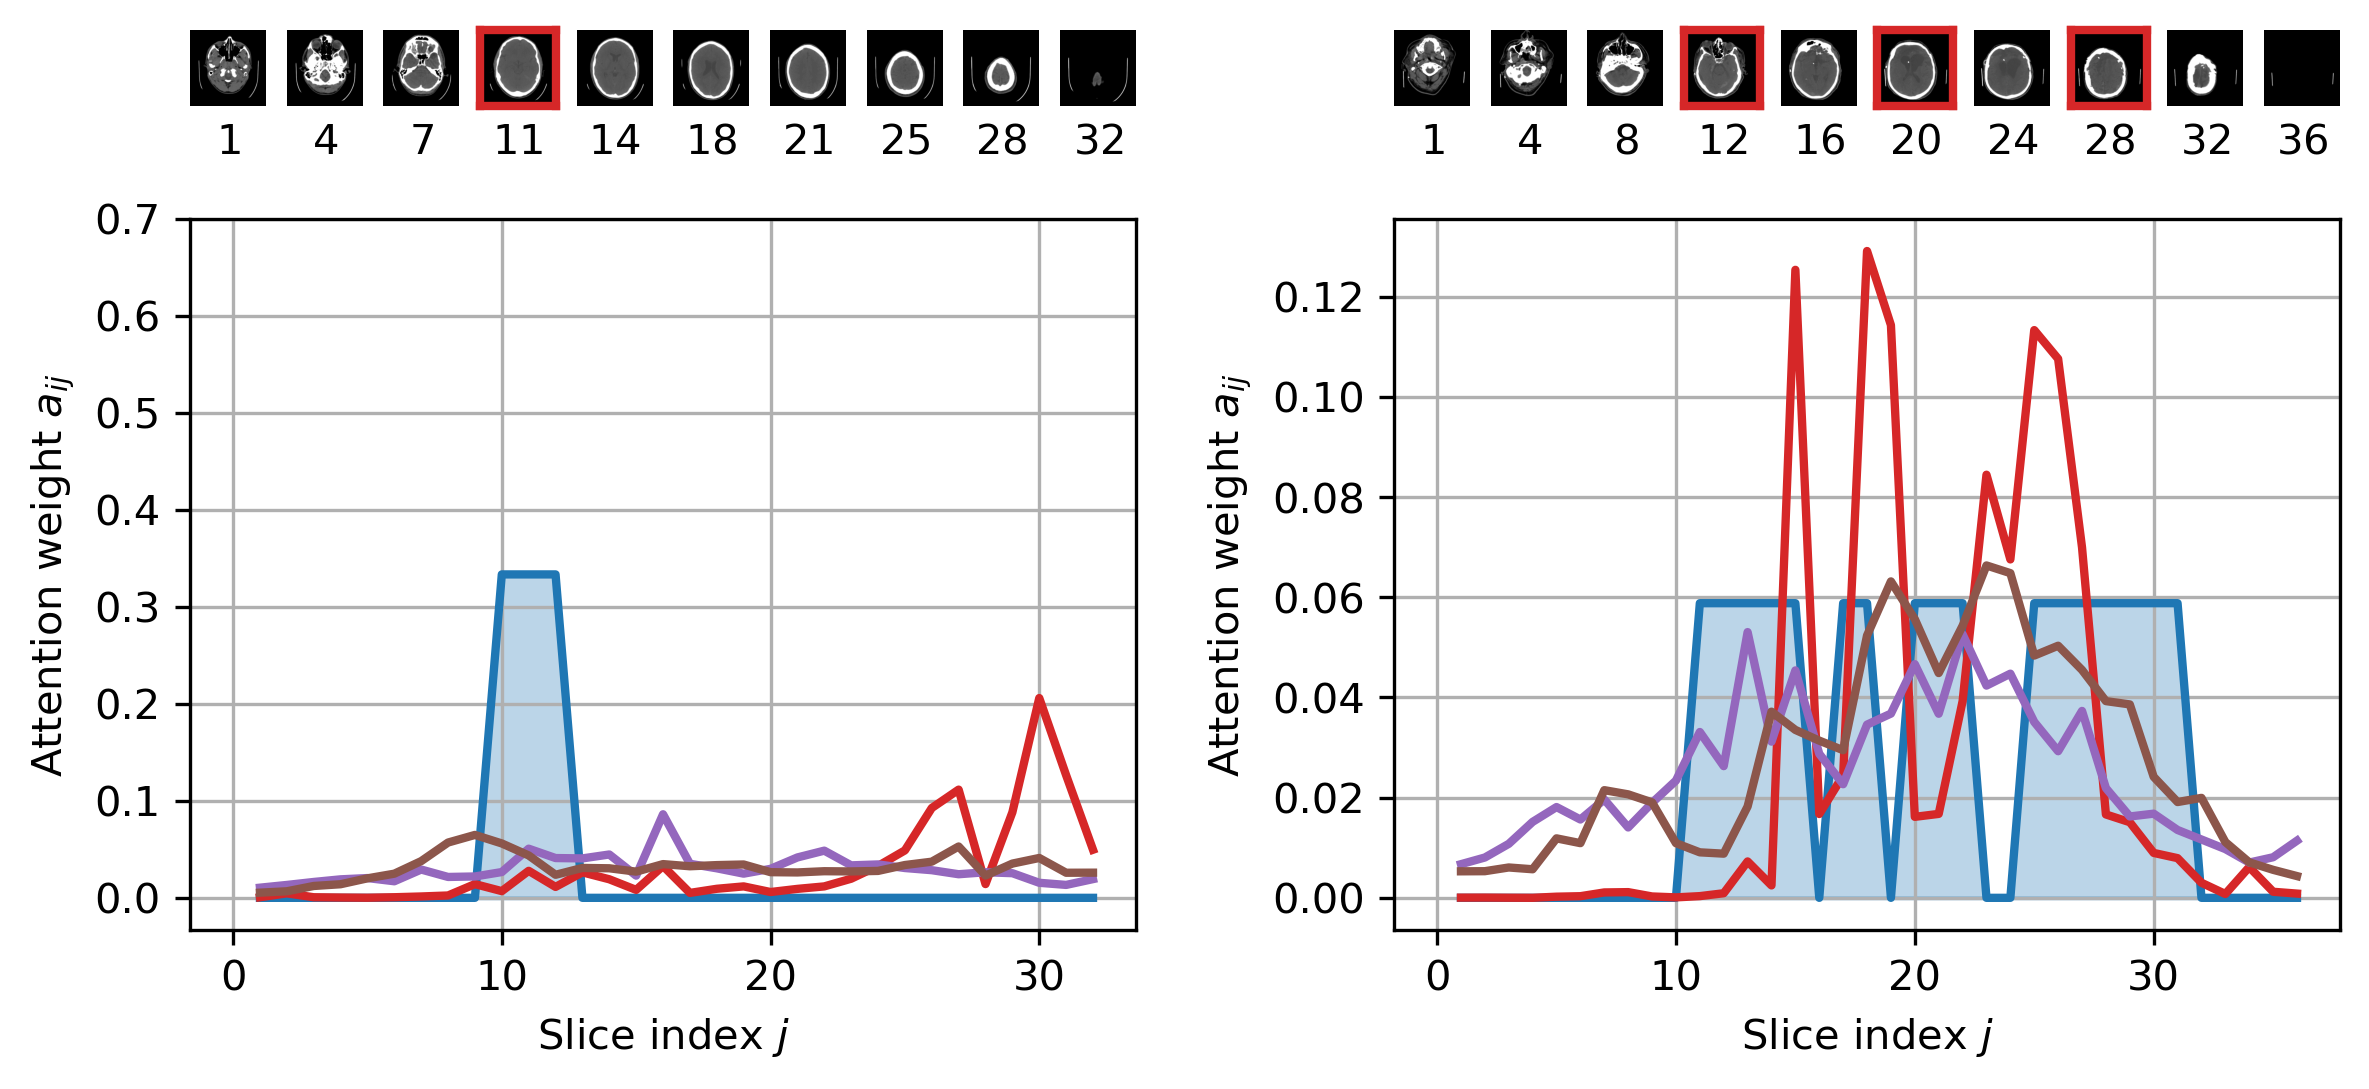

In [21]:
temp_df = test_df.reset_index()
sampled_df = temp_df[temp_df.ICH==1].iloc[2:4]
#sampled_df = temp_df[temp_df.ICH==1].sample(n=4, random_state=7)
#sampled_df = temp_df[temp_df.PE==1].sample(n=4, random_state=7)
#sampled_df = temp_df[temp_df.AT==1].sample(n=4, random_state=13)

fig, axs = plt.subplots(dpi=300, figsize=(8, 4), height_ratios=[1, 3], ncols=2, nrows=2)

subaxs = []

for i in range(2):
    gs = axs[0,i].get_gridspec()
    axs[0,i].remove()
    subgs = gs[0,i].subgridspec(1, 10)
    subaxs.append([fig.add_subplot(subgs[j]) for j in range(10)])
    
for i, (row_index, row) in enumerate(sampled_df.iterrows()):
    
    h_i, S_i, y_i = test_dataset[row_index]
    y_ij = row["Any"]
    #y_ij = row["pe_present_on_image"]
    #y_ij = row["instance_label"]
    study_id = row["Study ID"]
    #study_id = row["StudyInstanceUID"]
    #study_id = row["series_id"]
    numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH_numpy"
    #numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_PE_numpy"
    #numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_AT_numpy"
    image = np.load(f"{numpy_dir}/{study_id}.npz")["arr_0"]
    
    js = np.linspace(start=1, stop=S_i, num=10).astype(int)
        
    for k, j in enumerate(js):

        subaxs[i][k].imshow(image[0,:,:,j - 1], cmap="gray", vmin=np.min(image), vmax=np.max(image))
        subaxs[i][k].set_xlabel(rf"${j}$")

        subaxs[i][k].set_xticks([])
        subaxs[i][k].set_yticks([])

        for spine in subaxs[i][k].spines.values():
            if y_ij[j - 1] == 1:
                spine.set_visible(True)
                spine.set_color("#D62728")
                spine.set_linewidth(2)
            else:
                spine.set_visible(False)
                
    _, abmil_a_i = abmil_model(h_i, (S_i,))
    _, smap_a_i = smap_model(h_i, (S_i,))
    _, guided_abmil_a_i = guided_abmil_model(h_i, (S_i,))
    _, transmil_a_i = transmil_model(h_i, (S_i,))
    _, smtap_a_i = smtap_model(h_i, (S_i,))
    _, guided_transmil_a_i = guided_transmil_model(h_i, (S_i,))
    
    js = torch.arange(start=1, end=S_i + 1)
    
    axs[1,i].plot(js, (torch.tensor(y_ij) / sum(y_ij)).detach(), color="#1F77B4", label="Ground truth", linewidth=2)
    axs[1,i].fill_between(js, (torch.tensor(y_ij) / sum(y_ij)).detach(), alpha=0.3, color="#1F77B4")
    axs[1,i].scatter(0.0, 2 * (torch.tensor(y_ij) / sum(y_ij)).max().detach(), color="#FFFFFF")
    #axs[1,i].plot(js, abmil_a_i.detach(), color="#FF7F0E", label="ABMIL", linewidth=2)
    #axs[1,i].plot(js, smap_a_i.detach(), color="#2CA02C", label="Smooth Operator", linewidth=2)
    #axs[1,i].plot(js, guided_abmil_a_i.detach(), color="#D62728", label="Normal Guidance", linewidth=2)
    #axs[1,i].plot(js, transmil_a_i.mean(dim=1).detach(), color="#9467bd", label="TransMIL", linewidth=2)
    #axs[1,i].plot(js, smtap_a_i.mean(dim=1).detach(), color="#8c564b", label="Smooth Operator", linewidth=2)
    #axs[1,i].plot(js, guided_transmil_a_i.mean(dim=1).detach(), color="#e377c2", label="Normal Guidance", linewidth=2)
    
    
    axs[1,i].plot(js, abmil_a_i.detach(), color="#D62728", label="ABMIL", linewidth=2)
    axs[1,i].plot(js, transmil_a_i.mean(dim=1).detach(), color="#9467bd", label="TransMIL", linewidth=2)
    axs[1,i].plot(js, smap_a_i.detach(), color="#8C564B", label="SmAP", linewidth=2)
    
    axs[1,i].set_xlabel(r"Slice index $j$")
    axs[1,i].set_ylabel(r"Attention weight $a_{ij}$")
    axs[1,i].grid()
    
    #if i == 0:
    #    axs[1,i].legend(loc="upper left")
    
fig.tight_layout()
fig.savefig("abdomen_ct_transmil_visualizations.pdf", bbox_inches="tight")
plt.show()

In [3]:
dicom_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH"
labels_df = pd.read_csv(f"{dicom_dir}/full_dataset_labels.csv")
columns = ["Slice ID", "z", "Any"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
labels_df['ICH'] = labels_df.apply(lambda row: float(any(row.Any)), axis=1)
print(labels_df.shape)
labels_df.head()


(21744, 7)


,Patient ID,Study ID,Series ID,Slice ID,z,Any,ICH
0,ID_0002cd41,ID_66929e09d4,ID_e22a5534e6,"[ID_45785016b, ID_37f32aed2, ID_1b9de2922, ID_...","[35.968, 38.484, 41.0, 43.517, 46.033, 48.549,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
1,ID_00054f3f,ID_8a449ae31b,ID_15c3dd58c7,"[ID_138d275c8, ID_447fa09d9, ID_0f1298f68, ID_...","[71.9000244, 76.9000244, 81.9000244, 86.900024...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
2,ID_0006d192,ID_25690b4725,ID_4ec55fa0d7,"[ID_c6f9f68c9, ID_520df89aa, ID_b86dc15dd, ID_...","[38.171, 41.921, 45.671, 49.421, 53.171, 56.92...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
3,ID_00086119,ID_fdde2979b0,ID_caa405a7f2,"[ID_31b14de96, ID_203ef1efe, ID_9ce17ada6, ID_...","[32.955, 35.556, 38.156, 40.757, 43.358, 45.95...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
4,ID_000e5623,ID_9a4be35b9a,ID_0880626a95,"[ID_0785539ea, ID_30c100dbc, ID_3df0d63c3, ID_...","[272.0, 277.0, 282.0, 287.0, 292.0, 297.0, 302...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0


In [165]:
seed = 1001

grouped_df = labels_df.groupby("Patient ID")["ICH"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["Patient ID"], grouped_df["ICH"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["Patient ID"].isin(train_ids)]
val_df = labels_df[labels_df["Patient ID"].isin(val_ids)]
test_df = labels_df[labels_df["Patient ID"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [18]:
temp_df = test_df.reset_index()
study_id = "ID_7b5f7d75e1"
index = temp_df[temp_df["Study ID"] == study_id].index[0]
h_i, S_i, y_i = test_dataset[index]
y_ij = temp_df["Any"].iloc[index]
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH_numpy"
image = np.load(f"{numpy_dir}/{study_id}.npz")["arr_0"]

model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True"
model_name = "alpha=0.0001_criterion=L1_lr=0.0001_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

_, a_i = model(h_i, (S_i,))


experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.0001_pooling=TransMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

_, guided_a_i = model(h_i, (S_i,))


In [10]:
def get_x(y):
    return torch.arange(1, len(y) + 1, device=y.device, dtype=y.dtype).unsqueeze(1)

def calc_mean(y, eps=1e-6):
    x = get_x(y)
    sum_y = torch.clamp(y.sum(dim=0), min=eps)
    mean = (x * y).sum(dim=0) / sum_y
    return mean

def calc_std(y, eps=1e-6):
    x = get_x(y)
    sum_y = torch.clamp(y.sum(dim=0), min=eps)
    mean = (x * y).sum(dim=0) / sum_y
    variance = (x.pow(2) * y).sum(dim=0) / sum_y - mean.pow(2)
    variance = torch.clamp(variance, min=eps)
    return torch.sqrt(variance)


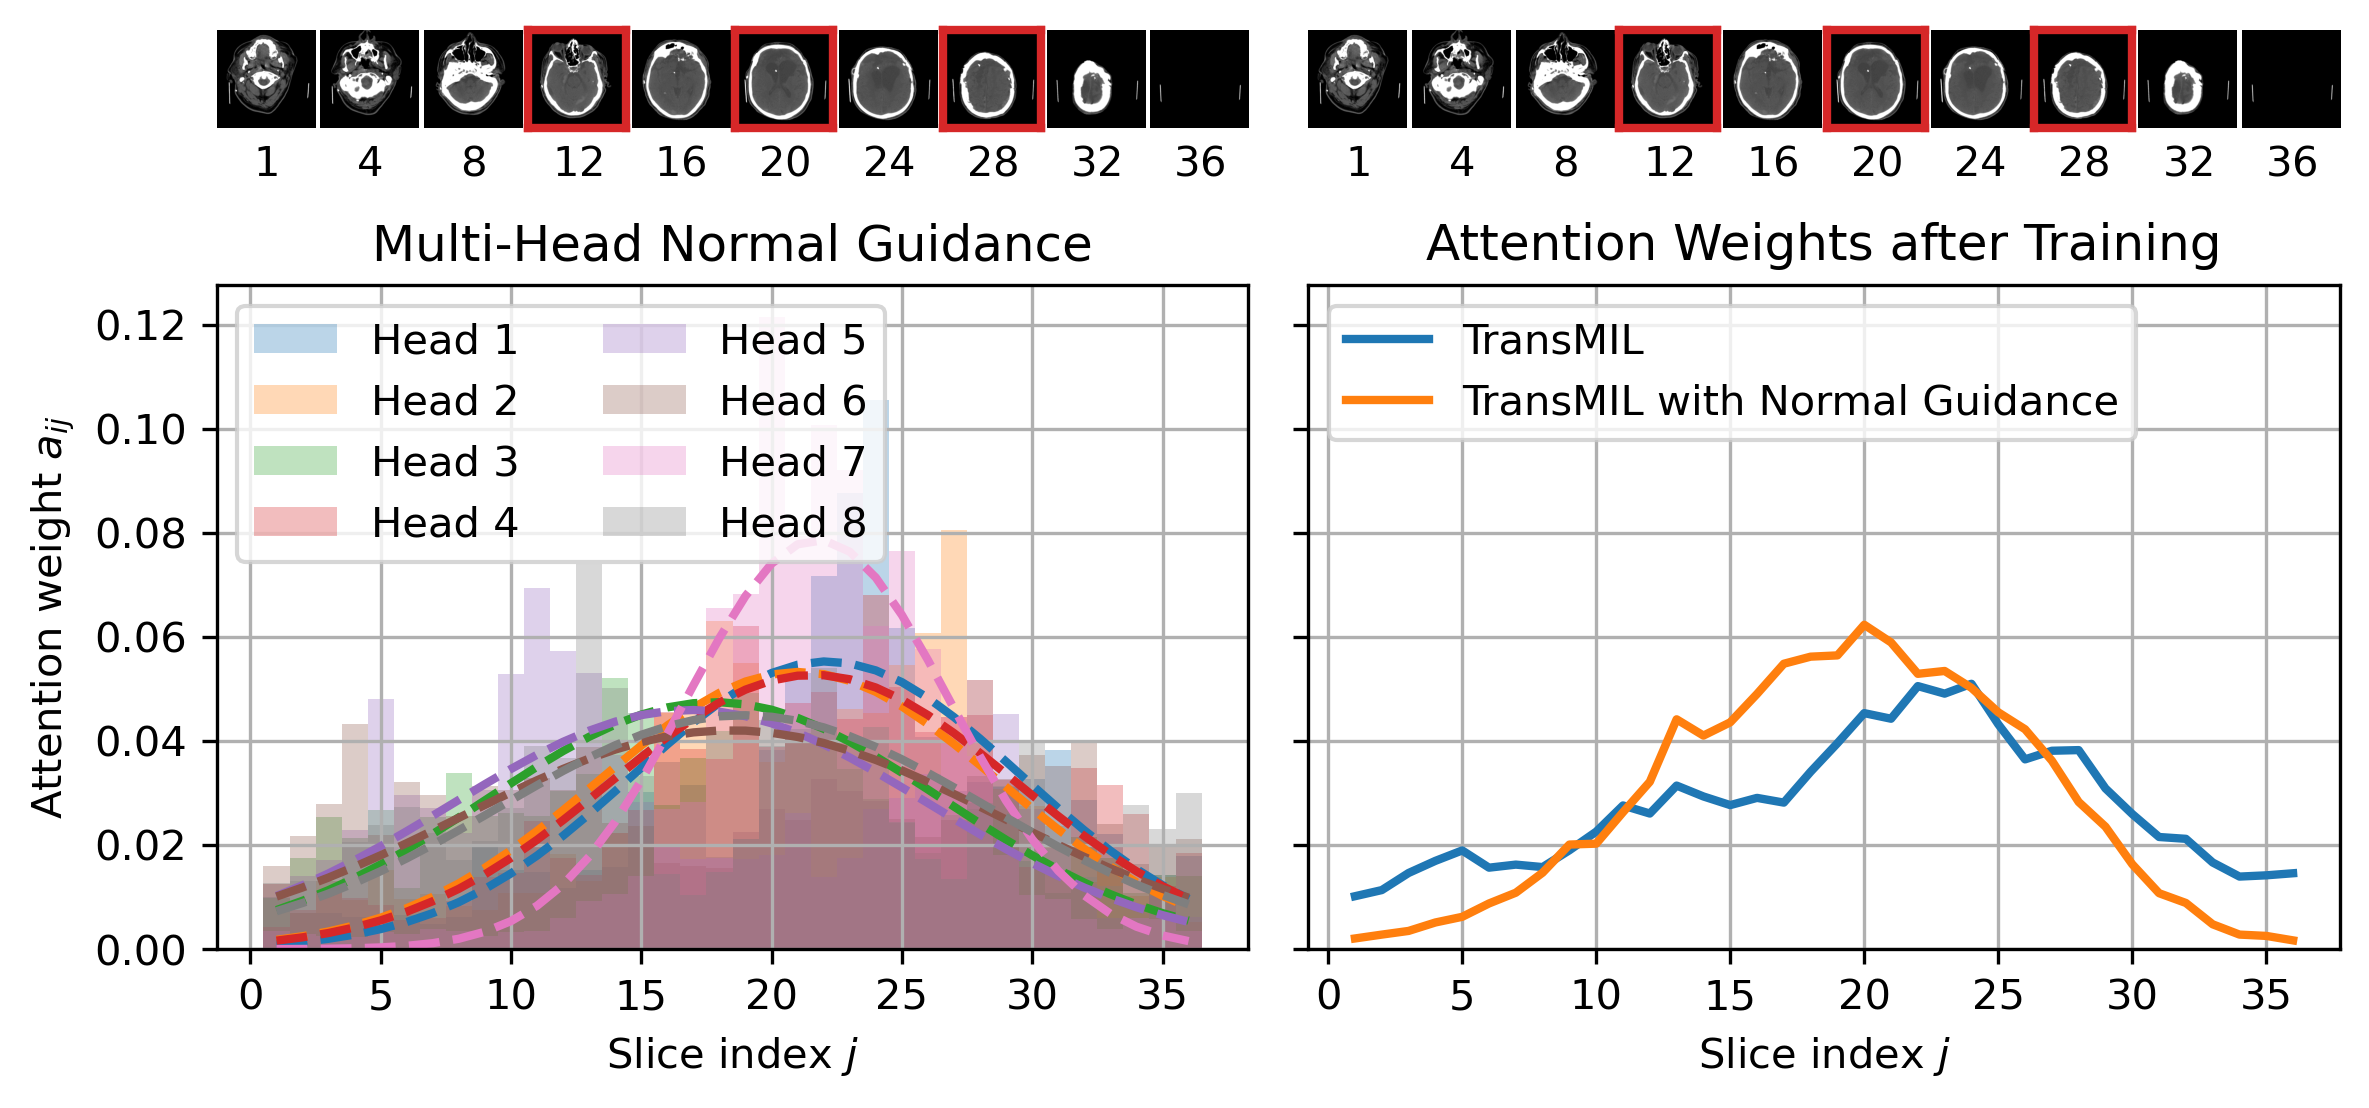

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(8, 4), dpi=300, height_ratios=[1, 3], sharey=True)

subaxs = []

for i in range(2):
    gs = axs[0,i].get_gridspec()
    axs[0,i].remove()
    subgs = gs[0,i].subgridspec(1, 10)
    subaxs.append([fig.add_subplot(subgs[j]) for j in range(10)])
    
js = np.linspace(start=1, stop=S_i, num=10).astype(int)

for i, j in enumerate(js):
    
    for subax in subaxs:

        subax[i].imshow(image[0,:,:,j - 1], cmap="gray", vmin=np.min(image), vmax=np.max(image))
        subax[i].set_xlabel(rf"${j}$")

        subax[i].set_xticks([])
        subax[i].set_yticks([])

        for spine in subax[i].spines.values():
            if y_ij[j - 1] == 1:
                spine.set_visible(True)
                spine.set_color("#D62728")
                spine.set_linewidth(2)
            else:
                spine.set_visible(False)
    
js = torch.arange(start=1, end=S_i + 1, dtype=torch.float32).unsqueeze(1)
r_hat_i = utils.normal_pdf(js, calc_mean(a_i), calc_std(a_i))
r_i = r_hat_i / torch.sum(r_hat_i, dim=0)

#axs[1,0].plot(js, torch.mean(a_i, dim=1).detach(), color="#9467BD", label="TransMIL", linewidth=2)
#axs[1,0].plot([], [], color="#000000", label="Normal", linestyle="--", linewidth=2)

axs[1,0].plot([1], 2 * torch.mean(a_i, dim=1).detach().max(), color="#FFFFFF")

colors = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD", "#8C564B", "#E377C2", "#7F7F7F", "#BCBD22", "#17BECF"]
for h, color in enumerate(colors[:8]):
    axs[1,0].bar(js.squeeze(), a_i[:,h].detach(), align="center", alpha=0.3, color=color, label=f"Head {h+1}", width=1.0)
    axs[1,0].plot(js, r_i[:,h].detach(), color=color, linestyle="--", linewidth=2)

axs[1,0].set_title("Multi-Head Normal Guidance")
axs[1,0].set_xlabel(r"Slice index $j$")
axs[1,0].set_ylabel(r"Attention weight $a_{ij}$")
axs[1,0].legend(loc="upper left", ncol=2)
axs[1,0].grid()

axs[1,1].plot(js, torch.mean(a_i, dim=1).detach(), color="#1F77B4", label="TransMIL", linewidth=2)
axs[1,1].plot(js, torch.mean(guided_a_i, dim=1).detach(), color="#FF7F0E", label="TransMIL with Normal Guidance", linewidth=2)

axs[1,1].set_title("Attention Weights after Training")
axs[1,1].set_xlabel(r"Slice index $j$")
axs[1,1].legend(loc="upper left")
axs[1,1].grid()

fig.tight_layout()
fig.savefig("multi-head_normal_guidance.pdf", bbox_inches="tight")
plt.show()

In [3]:
dicom_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH"
labels_df = pd.read_csv(f"{dicom_dir}/full_dataset_labels.csv")
columns = ["Slice ID", "z", "Any"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
labels_df['ICH'] = labels_df.apply(lambda row: float(any(row.Any)), axis=1)
print(labels_df.shape)
labels_df.head()


(21744, 7)


,Patient ID,Study ID,Series ID,Slice ID,z,Any,ICH
0,ID_0002cd41,ID_66929e09d4,ID_e22a5534e6,"[ID_45785016b, ID_37f32aed2, ID_1b9de2922, ID_...","[35.968, 38.484, 41.0, 43.517, 46.033, 48.549,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
1,ID_00054f3f,ID_8a449ae31b,ID_15c3dd58c7,"[ID_138d275c8, ID_447fa09d9, ID_0f1298f68, ID_...","[71.9000244, 76.9000244, 81.9000244, 86.900024...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
2,ID_0006d192,ID_25690b4725,ID_4ec55fa0d7,"[ID_c6f9f68c9, ID_520df89aa, ID_b86dc15dd, ID_...","[38.171, 41.921, 45.671, 49.421, 53.171, 56.92...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
3,ID_00086119,ID_fdde2979b0,ID_caa405a7f2,"[ID_31b14de96, ID_203ef1efe, ID_9ce17ada6, ID_...","[32.955, 35.556, 38.156, 40.757, 43.358, 45.95...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
4,ID_000e5623,ID_9a4be35b9a,ID_0880626a95,"[ID_0785539ea, ID_30c100dbc, ID_3df0d63c3, ID_...","[272.0, 277.0, 282.0, 287.0, 292.0, 297.0, 302...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0


In [4]:
seed = 1001

grouped_df = labels_df.groupby("Patient ID")["ICH"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["Patient ID"], grouped_df["ICH"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["Patient ID"].isin(train_ids)]
val_df = labels_df[labels_df["Patient ID"].isin(val_ids)]
test_df = labels_df[labels_df["Patient ID"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [6]:
test_df[test_df.ICH==1].head(10)

,Patient ID,Study ID,Series ID,Slice ID,z,Any,ICH
6,ID_0011dd8c,ID_7b5f7d75e1,ID_3d6598aed9,"[ID_0704693b1, ID_ad7e78886, ID_cc3f63d31, ID_...","[11.647, 14.172, 16.696, 19.221, 21.745, 24.27...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0
16,ID_00307f7a,ID_cba1ebce2b,ID_08e904eabc,"[ID_f77c0e7ba, ID_d5f6dfa83, ID_09f7a7c4c, ID_...","[54.889881, 60.066261, 65.242645, 70.419022, 7...","[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.0
61,ID_00c512c7,ID_9d9287fee9,ID_412156a1a8,"[ID_caff0bd9e, ID_fd743d51c, ID_f49d0a793, ID_...","[20.631552, 25.820263, 31.008974, 36.197685, 4...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, ...",1.0
65,ID_00d2db12,ID_7f66131e04,ID_a16f59f4e1,"[ID_d44577a7d, ID_93dbee153, ID_de1154883, ID_...","[-29.677, -24.565, -19.454, -14.342, -9.232, -...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, ...",1.0
77,ID_00e394df,ID_bf7891541c,ID_5a72a00c10,"[ID_fd503db37, ID_207824a0b, ID_abc0e21ec, ID_...","[21.74, 24.317, 26.893, 29.47, 32.046, 34.623,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0
89,ID_010f1536,ID_5b4e6ff8eb,ID_6299317a02,"[ID_4e902d39c, ID_94451c029, ID_be1695414, ID_...","[79.025, 81.818, 84.612, 87.405, 90.199, 92.99...","[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...",1.0
115,ID_01682629,ID_b34772b37b,ID_5e02b5c638,"[ID_f34ed5b90, ID_61bc9d319, ID_4da315970, ID_...","[-9.771, -4.298, 1.175, 6.648, 12.124, 17.597,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...",1.0
128,ID_018a0378,ID_7a569b3064,ID_e427ca5f40,"[ID_54b0b9abc, ID_0c6b59540, ID_1b962c588, ID_...","[76.985868, 82.04141, 87.0858436, 92.1413856, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...",1.0
144,ID_01a8bbad,ID_ae257e829b,ID_217a5afbbd,"[ID_54682b3ad, ID_dd34668a4, ID_06141390f, ID_...","[49.056114, 54.448788, 59.841461, 65.234131, 7...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...",1.0
146,ID_01ac7faf,ID_ad9d58d899,ID_0948faf632,"[ID_23d4e1537, ID_9babd2d48, ID_ab3cd70e9, ID_...","[-39.628666, -34.235989, -28.843319, -23.45064...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0


In [119]:
temp_df = test_df.reset_index()
study_id = "ID_7b5f7d75e1"
index = temp_df[temp_df["Study ID"] == study_id].index[0]
h_i, S_i, y_i = test_dataset[index]
y_ij = temp_df["Any"].iloc[index]
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH_numpy"
image = np.load(f"{numpy_dir}/{study_id}.npz")["arr_0"]

model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True"
model_name = "alpha=0.0001_criterion=L1_lr=0.1_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

_, a_i = model(h_i, (S_i,))

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=squared_error"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

_, squared_a_i = model(h_i, (S_i,))


experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

_, forward_a_i = model(h_i, (S_i,))

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=reverse"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=1001"
checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

_, reverse_a_i = model(h_i, (S_i,))


In [120]:
def get_x(y):
    return torch.arange(1, len(y) + 1, device=y.device, dtype=y.dtype).unsqueeze(1)

def calc_mean(y, eps=1e-6):
    x = get_x(y)
    sum_y = torch.clamp(y.sum(dim=0), min=eps)
    mean = (x * y).sum(dim=0) / sum_y
    return mean

def calc_std(y, eps=1e-6):
    x = get_x(y)
    sum_y = torch.clamp(y.sum(dim=0), min=eps)
    mean = (x * y).sum(dim=0) / sum_y
    variance = (x.pow(2) * y).sum(dim=0) / sum_y - mean.pow(2)
    variance = torch.clamp(variance, min=eps)
    return torch.sqrt(variance)


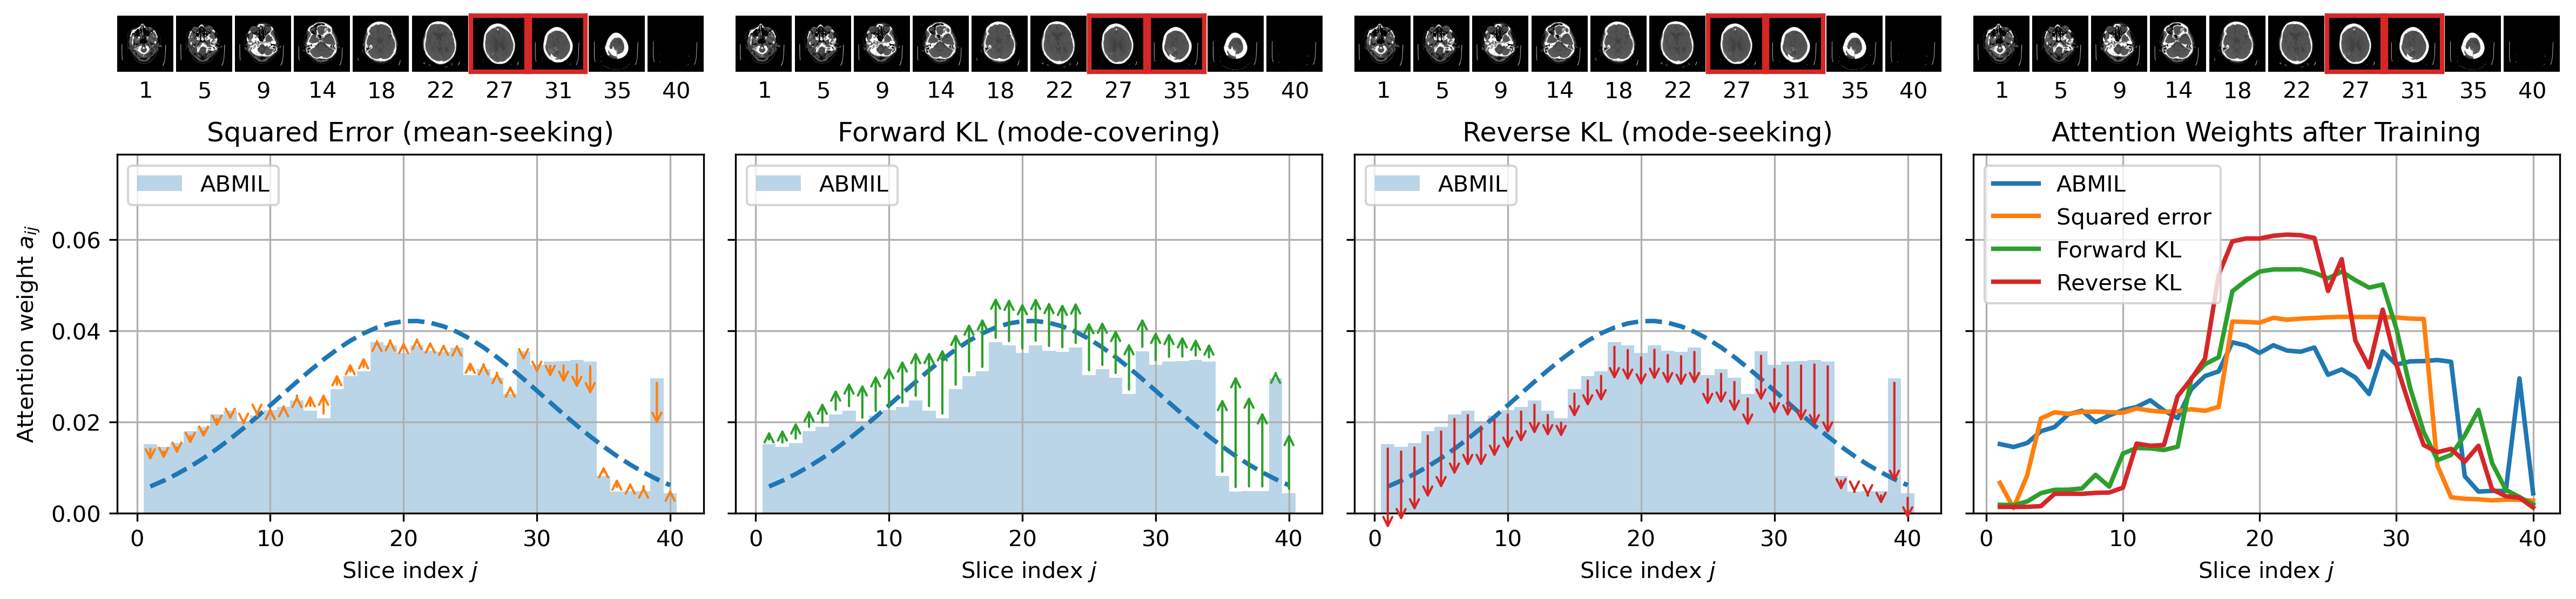

In [129]:
fig, axs = plt.subplots(2, 4, figsize=(16, 4), dpi=300, height_ratios=[1, 3], sharey=True)

subaxs = []

for i in range(4):
    gs = axs[0,i].get_gridspec()
    axs[0,i].remove()
    subgs = gs[0,i].subgridspec(1, 10)
    subaxs.append([fig.add_subplot(subgs[j]) for j in range(10)])
    
js = np.linspace(start=1, stop=S_i, num=10).astype(int)

for i, j in enumerate(js):
    
    for subax in subaxs:

        subax[i].imshow(image[0,:,:,j - 1], cmap="gray", vmin=np.min(image), vmax=np.max(image))
        subax[i].set_xlabel(rf"${j}$")

        subax[i].set_xticks([])
        subax[i].set_yticks([])

        for spine in subax[i].spines.values():
            if y_ij[j - 1] == 1:
                spine.set_visible(True)
                spine.set_color("#D62728")
                spine.set_linewidth(2)
            else:
                spine.set_visible(False)
            
js = torch.arange(start=1, end=S_i + 1).unsqueeze(1)
r_hat_i = utils.normal_pdf(js, calc_mean(a_i), calc_std(a_i))
r_i = r_hat_i / r_hat_i.sum()

axs[1,0].bar(js.squeeze(), a_i[:,0].detach(), align="center", alpha=0.3, color="#1F77B4", label="ABMIL", width=1.0)
axs[1,0].plot([1], 2 * torch.sum(a_i, dim=1).detach().max(), color="#FFFFFF")
axs[1,0].plot(js, r_i[:,0].detach(), color="#1F77B4", linestyle="--", linewidth=2)

for j, a_ij, r_ij in zip(js, a_i, r_i):
    axs[1,0].annotate(
        "", 
        xy=(j, a_ij),
        xytext=(j, a_ij - 0.25 * 2 * (a_ij - r_ij)),
        arrowprops=dict(arrowstyle="<-", color="#FF7F0E", lw=1)
    )

axs[1,0].set_title("Squared Error (mean-seeking)")
axs[1,0].set_xlabel(r"Slice index $j$")
axs[1,0].set_ylabel(r"Attention weight $a_{ij}$")
axs[1,0].legend(loc="upper left")
axs[1,0].grid()

axs[1,1].bar(js.squeeze(), a_i[:,0].detach(), align="center", alpha=0.3, color="#1F77B4", label="ABMIL", width=1.0)
axs[1,1].plot([1], 2 * torch.sum(a_i, dim=1).detach().max(), color="#FFFFFF")
axs[1,1].plot(js, r_i[:,0].detach(), color="#1F77B4", linestyle="--", linewidth=2)

for j, a_ij, r_ij in zip(js, a_i, r_i):
    axs[1,1].annotate(
        "", 
        xy=(j, a_ij),
        xytext=(j, a_ij + 0.01 * (r_ij / a_ij)),
        arrowprops=dict(arrowstyle="<-", color="#2CA02C", lw=1)
    )

axs[1,1].set_title("Forward KL (mode-covering)")
axs[1,1].set_xlabel(r"Slice index $j$")
axs[1,1].legend(loc="upper left")
axs[1,1].grid()

axs[1,2].bar(js.squeeze(), a_i[:,0].detach(), align="center", alpha=0.3, color="#1F77B4", label="ABMIL", width=1.0)
axs[1,2].plot(js, r_i.detach(), color="#1F77B4", linestyle="--", linewidth=2)

for j, a_ij, r_ij in zip(js, a_i, r_i):
    axs[1,2].annotate(
        "", 
        xy=(j, a_ij),
        xytext=(j, a_ij - 0.01 * (torch.log(a_ij) + 1.0 - torch.log(r_ij))),
        arrowprops=dict(arrowstyle="<-", color="#D62728", lw=1)
    )

axs[1,2].set_title("Reverse KL (mode-seeking)")
axs[1,2].set_xlabel(r"Slice index $j$")
axs[1,2].legend(loc="upper left")
axs[1,2].grid()

axs[1,3].plot(js, a_i.detach(), color="#1F77B4", label="ABMIL", linewidth=2)
axs[1,3].plot(js, squared_a_i.detach(), color="#FF7F0E", label="Squared error", linewidth=2)
axs[1,3].plot(js, forward_a_i.detach(), color="#2CA02C", label="Forward KL", linewidth=2)
axs[1,3].plot(js, reverse_a_i.detach(), color="#D62728", label="Reverse KL", linewidth=2)
axs[1,3].set_title("Attention Weights after Training")
axs[1,3].set_xlabel(r"Slice index $j$")
axs[1,3].legend(loc="upper left")
axs[1,3].grid()

fig.tight_layout()
fig.savefig("varying_the_divergence_measure.pdf", bbox_inches="tight")
plt.show()